# **PMDSSC 103 Assgnment 1**
Levi P. Caaya III

## Import Modules

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import kagglehub
from kagglehub import KaggleDatasetAdapter

## Loading Dataset from Kaggle




Note: I used direct uploading in the previous activity and realized that rerunning will cause an error since colab deletes runtime files



In [2]:
file_path = "FuelConsumption (1).csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,"krupadharamshi/fuelconsumption",file_path,)
df

/tmp/ipython-input-1980537554.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 34.0k/34.0k [00:00<00:00, 8.97MB/s]


,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,10.5,216
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,9.8,205
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.7,265
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,11.4,230
...,...,...,...,...,...,...,...,...,...,...
634,2000,VOLVO,V70 AWD TURBO,STATION WAGON - MID-SIZE,2.4,5,A4,Z,14.4,288
635,2000,VOLVO,V70 GLT TURBO,STATION WAGON - MID-SIZE,2.4,5,A4,Z,13.6,274
636,2000,VOLVO,V70 T5 TURBO,STATION WAGON - MID-SIZE,2.3,5,A4,Z,13.9,274
637,2000,VOLVO,V70 T5 TURBO,STATION WAGON - MID-SIZE,2.3,5,M5,Z,13.0,260


## Exploring the data

In [3]:
df.head(10)
#first ten elements

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,10.5,216
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,9.8,205
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.7,265
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,11.4,230
5,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,M5,X,10.6,219
6,2000,ACURA,INTEGRA GSR/TYPE R,SUBCOMPACT,1.8,4,M5,Z,10.8,223
7,2000,ACURA,NSX,SUBCOMPACT,3.0,6,AS4,Z,15.2,306
8,2000,ACURA,NSX,SUBCOMPACT,3.2,6,M6,Z,15.4,306
9,2000,AUDI,A4,COMPACT,1.8,4,A5,Z,12.9,251


In [4]:
df.tail()

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
634,2000,VOLVO,V70 AWD TURBO,STATION WAGON - MID-SIZE,2.4,5,A4,Z,14.4,288
635,2000,VOLVO,V70 GLT TURBO,STATION WAGON - MID-SIZE,2.4,5,A4,Z,13.6,274
636,2000,VOLVO,V70 T5 TURBO,STATION WAGON - MID-SIZE,2.3,5,A4,Z,13.9,274
637,2000,VOLVO,V70 T5 TURBO,STATION WAGON - MID-SIZE,2.3,5,M5,Z,13.0,260
638,2000,VOLVO,V70R AWD TURBO,STATION WAGON - MID-SIZE,2.4,5,A5,Z,14.7,299


In [5]:
df.shape

(639, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              639 non-null    int64  
 1   MAKE              639 non-null    object 
 2   MODEL             639 non-null    object 
 3   VEHICLE CLASS     639 non-null    object 
 4   ENGINE SIZE       639 non-null    float64
 5   CYLINDERS         639 non-null    int64  
 6   TRANSMISSION      639 non-null    object 
 7   FUEL              639 non-null    object 
 8   FUEL CONSUMPTION  639 non-null    float64
 9   COEMISSIONS       639 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 50.1+ KB


In [7]:
df.describe()

,Year,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,COEMISSIONS
count,639.0,639.000000,639.000000,639.000000,639.000000
mean,2000.0,3.265728,5.805947,14.713615,296.809077
std,0.0,1.231012,1.625588,3.307044,65.504178
min,2000.0,1.000000,3.000000,4.900000,104.000000
25%,2000.0,2.200000,4.000000,12.500000,253.000000
50%,2000.0,3.000000,6.000000,14.400000,288.000000
75%,2000.0,4.300000,6.000000,16.600000,343.000000
max,2000.0,8.000000,12.000000,30.200000,582.000000


In [8]:
df.columns

Index(['Year', 'MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUEL', 'FUEL CONSUMPTION', 'COEMISSIONS '],
      dtype='object')

In [9]:
df.rename(columns=lambda coltitle: coltitle.strip(), inplace=True)
#COEMISSIONS has trailing space, we need to remove that to prevent bugs

In [10]:
df.columns

Index(['Year', 'MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINE SIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUEL', 'FUEL CONSUMPTION', 'COEMISSIONS'],
      dtype='object')

it is now fixed

## Preparing the data

In [11]:
x = df.drop('FUEL CONSUMPTION', axis = 1)
#independet variable

In [12]:
y = df['FUEL CONSUMPTION']

Fix categorical data by using dummies


In [13]:
x_states = pd.get_dummies(x, drop_first=True)
x_states


,Year,ENGINE SIZE,CYLINDERS,COEMISSIONS,MAKE_AUDI,MAKE_BMW,MAKE_BUICK,MAKE_CADILLAC,MAKE_CHEVROLET,MAKE_CHRYSLER,...,TRANSMISSION_A5,TRANSMISSION_AS4,TRANSMISSION_AS5,TRANSMISSION_AS6,TRANSMISSION_M5,TRANSMISSION_M6,FUEL_E,FUEL_N,FUEL_X,FUEL_Z
0,2000,1.6,4,216,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,2000,1.6,4,205,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,2000,3.2,6,265,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,2000,3.5,6,301,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2000,1.8,4,230,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634,2000,2.4,5,288,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
635,2000,2.4,5,274,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
636,2000,2.3,5,274,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
637,2000,2.3,5,260,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [14]:
x = x_states
#assign this to the dependent variable

In [15]:
from sklearn.model_selection import train_test_split
# Training - 80% , Testing 20%
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(x_train,y_train)

LinearRegression()

In [17]:
y_prediction = LR.predict(x_test)
y_prediction

array([13.77968595, 17.74804437, 14.48994833, 25.87897228, 14.45228288,
       13.37206894, 14.5827334 , 15.04907116, 21.16651995, 16.72232675,
       11.22528155, 11.880353  , 15.68657083, 10.96320471, 12.55536745,
        9.97815563, 13.55170591, 12.45170591,  9.97815563, 11.85925215,
       13.89524363, 17.07769351, 15.80125108, 12.06011152, 16.25939712,
       21.46070501, 21.17469495, 11.98794325,  8.8299864 , 14.71041001,
       15.63327813, 13.88681913, 19.26037573, 16.7857982 , 15.42949173,
       11.02677624, 13.38630161, 18.22923728, 12.19624315, 12.50527185,
       14.75067312, 10.26247101, 30.38824924, 12.95097686, 18.93747229,
       13.07799656, 15.68522898, 17.97793513, 14.71085992, 11.88480921,
       14.36284805, 12.34381361, 15.60281984, 14.49280178, 15.29205853,
       20.70000263, 18.1783489 , 12.18099822, 26.53105091, 19.34486885,
       18.84882787, 17.76027754, 17.38023335, 10.9862894 , 15.86578168,
       15.78181717, 11.79905806, 13.94188725, 15.31101535, 13.36

Evaluate Initial Model

In [18]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
score = r2_score(y_test,y_prediction)
mean_square_error = mean_squared_error (y_test,y_prediction)
root_mean_squared = np.sqrt(mean_squared_error(y_test,y_prediction))

score

0.9941975668381586

In [19]:
mean_square_error

0.08105443461953786

In [20]:
root_mean_squared

np.float64(0.28470060523212426)

In [21]:
from sklearn.feature_selection import f_regression

In [22]:
f_regression(x,y)

(array([0.00000000e+00, 1.78004443e+03, 1.36563558e+03, 1.85176711e+04,
        7.49651904e-01, 2.08337776e-03, 1.65459879e-01, 1.43870241e+00,
        5.27413256e+00, 2.14117170e+00, 8.02727418e+00, 8.48075911e+01,
        1.02724153e+02, 1.18477327e+01, 3.52050052e+01, 1.92735255e+01,
        8.30780029e+00, 5.19592085e-01, 1.06483120e+00, 9.22086426e-01,
        2.30290581e+00, 2.19282990e+00, 1.13612231e+01, 4.29498292e-02,
        1.67154256e+00, 3.42101452e+00, 6.20488958e-02, 2.31863083e-01,
        8.19293768e-01, 4.30808196e-02, 8.89866020e+00, 5.02430429e-01,
        1.07697976e+00, 2.00927981e+01, 7.47209883e+00, 1.88037066e+01,
        1.09229101e+01, 3.22589297e+01, 2.04318362e+00, 9.39570081e-02,
        7.49936728e-03, 8.99329620e-03, 3.93706090e-02, 3.16214688e-01,
        3.16214688e-01, 2.92589871e-01, 2.92589871e-01, 1.74747941e+01,
        2.65029972e+01, 2.65029972e+01, 1.05742918e-01, 1.52918842e-01,
        4.90320432e-03, 1.28153390e-01, 5.65494019e-02, 2.271084

In [23]:
p_values = f_regression(x,y)[1]
p_values

array([1.00000000e+000, 1.28273573e-186, 1.38264916e-160, 0.00000000e+000,
       3.86912437e-001, 9.63608277e-001, 6.84315320e-001, 2.30795389e-001,
       2.19682228e-002, 1.43885578e-001, 4.75362427e-003, 4.68714909e-019,
       1.75371690e-022, 6.15103716e-004, 4.87216214e-009, 1.32592558e-005,
       4.08054237e-003, 4.71280186e-001, 3.02507503e-001, 3.37292079e-001,
       1.29628325e-001, 1.39148798e-001, 7.95255872e-004, 8.35886003e-001,
       1.96520765e-001, 6.48344537e-002, 8.03366697e-001, 6.30311183e-001,
       3.65728946e-001, 8.35639505e-001, 2.96293741e-003, 4.78693478e-001,
       2.99767954e-001, 8.74831003e-006, 6.44028337e-003, 1.68394673e-005,
       1.00310207e-003, 2.05267169e-008, 1.53379595e-001, 7.59305817e-001,
       9.31017564e-001, 9.24477305e-001, 8.42779557e-001, 5.74089234e-001,
       5.74089234e-001, 5.88754738e-001, 5.88754738e-001, 3.31880638e-005,
       3.51069056e-007, 3.51069056e-007, 7.45150588e-001, 6.95892227e-001,
       9.44197422e-001, 7

In [24]:
p_values.round(3)

array([1.   , 0.   , 0.   , 0.   , 0.387, 0.964, 0.684, 0.231, 0.022,
       0.144, 0.005, 0.   , 0.   , 0.001, 0.   , 0.   , 0.004, 0.471,
       0.303, 0.337, 0.13 , 0.139, 0.001, 0.836, 0.197, 0.065, 0.803,
       0.63 , 0.366, 0.836, 0.003, 0.479, 0.3  , 0.   , 0.006, 0.   ,
       0.001, 0.   , 0.153, 0.759, 0.931, 0.924, 0.843, 0.574, 0.574,
       0.589, 0.589, 0.   , 0.   , 0.   , 0.745, 0.696, 0.944, 0.72 ,
       0.812, 0.   , 0.195, 0.836, 0.836, 0.185, 0.407, 0.632, 0.632,
       0.673, 0.627, 0.285, 0.549, 0.931, 0.836, 0.752, 0.812, 0.048,
       0.604, 0.22 , 0.144, 0.299, 0.282, 0.489, 0.417, 0.653, 0.367,
       0.543, 0.612, 0.497, 0.361, 0.511, 0.186, 0.924, 0.907, 0.852,
       0.753, 0.503, 0.543, 0.997, 0.048, 0.048, 0.08 , 0.205, 0.034,
       0.034, 0.644, 0.524, 0.228, 0.861, 0.187, 0.275, 0.829, 0.978,
       0.225, 0.997, 0.113, 0.378, 0.018, 0.626, 0.582, 0.604, 0.051,
       0.249, 0.023, 0.584, 0.736, 0.924, 0.883, 0.665, 0.883, 0.014,
       0.919, 0.245,

In [25]:
reg_summary = pd.DataFrame(data = x.columns.values, columns=['Features'])
reg_summary ['p-values'] = p_values.round(3)
reg_summary

,Features,p-values
0,Year,1.000
1,ENGINE SIZE,0.000
2,CYLINDERS,0.000
3,COEMISSIONS,0.000
4,MAKE_AUDI,0.387
...,...,...
385,TRANSMISSION_M6,0.000
386,FUEL_E,0.012
387,FUEL_N,0.065
388,FUEL_X,0.453


In [26]:
df.select_dtypes(include='number').corr()


,Year,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,COEMISSIONS
Year,NaN,NaN,NaN,NaN,NaN
ENGINE SIZE,NaN,1.000000,0.893819,0.858170,0.849714
CYLINDERS,NaN,0.893819,1.000000,0.825784,0.798447
FUEL CONSUMPTION,NaN,0.858170,0.825784,1.000000,0.983232
COEMISSIONS,NaN,0.849714,0.798447,0.983232,1.000000


## Visualization

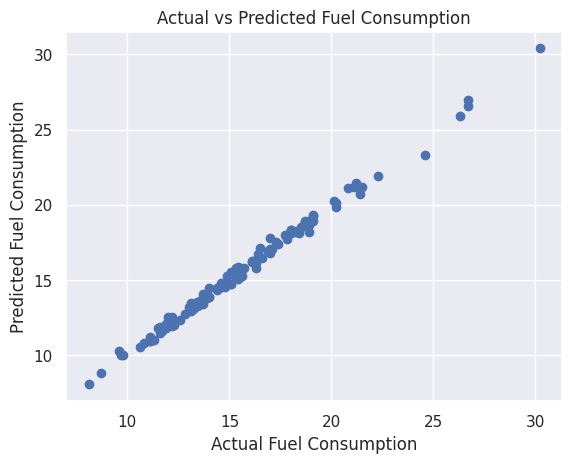

In [27]:
plt.scatter(y_test, y_prediction)
plt.xlabel("Actual Fuel Consumption")
plt.ylabel("Predicted Fuel Consumption")
plt.title("Actual vs Predicted Fuel Consumption")
plt.show()

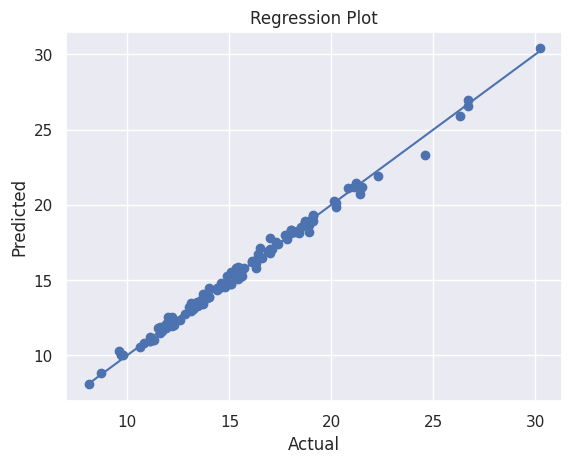

In [28]:
#regression plot
plt.scatter(y_test, y_prediction)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Regression Plot")
plt.show()


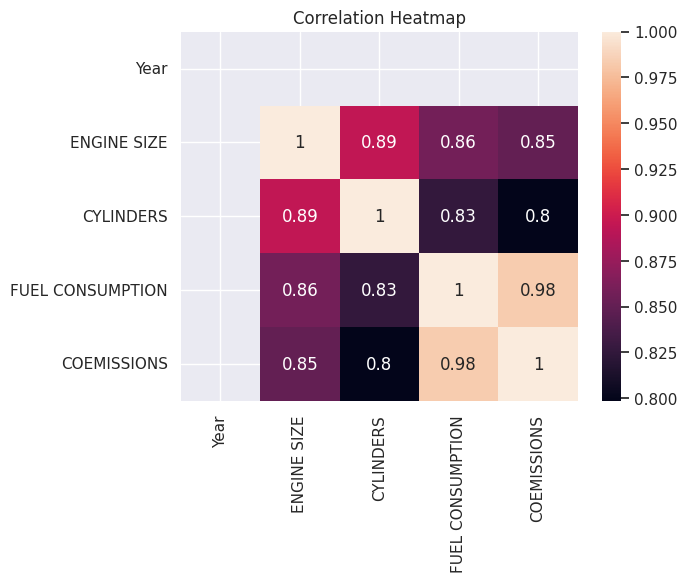

In [29]:
#heatmap

numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


**Note: The model achieved an R2 score of 0.99, proving an excellent fit. This high performance may be due to direct relation of the predictors to the fuel consumption. The uploader of the dataset in Kaggle did not specify if this is a real-world data or just an engineered data for linear regression simulation. Only the Year predicor shows no relation to fuel consumption as they are all year 2000**